## SphereDetect example

The [FocusScore](https://cellprofiler-manual.s3.amazonaws.com/CellProfiler-4.0.5/modules/measurement.html#:~:text=Measurements%20made%20by%20this%20module,-Blur%20metrics&text=FocusScore%3A%20A%20measure%20of%20the,scores%20correspond%20to%20lower%20bluriness) or [Normalized Variance](https://analyticalsciencejournals.onlinelibrary.wiley.com/doi/epdf/10.1002/jemt.20118) can measure how in focus an image is.

We can make use of this to find the starting point of a spheroid. 

As making an image stack, the spheroid will suddenly be in focus, or the change in FocusScore is large. 

We take the maximum change in focus as the starting point of each spheroid. 






In [11]:
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import os

import tifffile as tiff

import time


In [12]:
def calculate_normalized_variance(data):
    return np.var(data) / np.mean(data)

def read_image1(image):
    return tiff.TiffFile(image).asarray()
    
def read_image2(image):
    with tiff.TiffFile(image) as tf:
        data = tf.asarray()
    return data

def assign_plane(group, offset_addition=1):
    idxmax = group['d_normalized_variance'].idxmax()
    offset = group.index.get_loc(idxmax) - offset_addition # Offset by 1 to account for 0-based indexing
    
    planes = (np.arange(len(group)) - offset)
    # planes = np.where(planes < 0, pd.NA, planes)# Replace negative plane values (i.e. rows before max) with NaN
    
    group['Metadata_Plane'] = pd.Series(planes, index=group.index, dtype='Int64')
    return group

In [5]:
# cellprofiler_output = '/share/data/cellprofiler/automation/results/AssayPlate_Corning_3830/5514/8903/featICF_Image.parquet' # Load the image URLS from here
cellprofiler_output = '/share/data/cellprofiler/automation/results/AssayPlate_Corning_3830/5514/8905/icf_images_AssayPlate_Corning_3830.parquet' # Load the image URLS from here
channel = 'URL_SYTO' # One channel might be enough

In [6]:
# Import the image URLs
df = pd.read_parquet(cellprofiler_output)
df['URL_SphereDetect'] = df[channel].str.split(':').apply(lambda parts: ':'.join(parts[1:]))
df['Metadata_Z'] = df['FileName_SYTO'].str.extract(r'Z(\d+)C').astype(int) # Extract the Z slice number from the filename, there might be a better way to do this in the CellProfiler pipeline
df['URL_SphereDetect'] = df['URL_SphereDetect'].str.replace('/share/data/external-datasets/', '/mnt/external-images-pvc/') # This is specific to the way the data is stored in our database

In [8]:
df['URL_SphereDetect'][0]

'/mnt/external-images-pvc/spher-colo52-az/CellPainting_20241220clearedspheroidsBOMI_20241220_151510/AssayPlate_Corning_3830/AssayPlate_Corning_3830_B02_T0001F001L01A03Z01C03.tif'

In [13]:

# Calculate the start time
start = time.time()

# Code here

# Calculate the normalized variance for each image
df['normalized_variance'] = df['URL_SphereDetect'].apply(lambda image: calculate_normalized_variance(read_image1(image))) # Calculate the normalized variance for each image


# Calculate the end time and time taken
end = time.time()
length = end - start

# Show the results : this can be altered however you like
print("It took", length, "seconds!")

It took 341.3971905708313 seconds!


In [14]:

# Calculate the start time
start = time.time()

# Code here

# Calculate the normalized variance for each image
df['normalized_variance'] = df['URL_SphereDetect'].apply(lambda image: calculate_normalized_variance(read_image2(image))) # Calculate the normalized variance for each image


# Calculate the end time and time taken
end = time.time()
length = end - start

# Show the results : this can be altered however you like
print("It took", length, "seconds!")

It took 189.61977672576904 seconds!


In [6]:
# Calculate the normalized variance for each image
df['normalized_variance'] = df['URL_SphereDetect'].apply(lambda image: calculate_normalized_variance(read_image(image))) # Calculate the normalized variance for each image


In [7]:
# Caluclate the differential normalized variance
df = (
    df.sort_values(['Metadata_Well', 'Metadata_Z'])
      .assign(d_normalized_variance=lambda x: 
              x.groupby('Metadata_Well')['normalized_variance'].diff())
)

In [8]:
# Assign the plane number
df = (
    df.sort_values(['Metadata_Well', 'Metadata_Z'])
      .groupby('Metadata_Well', group_keys=False)
      .apply(assign_plane)
)

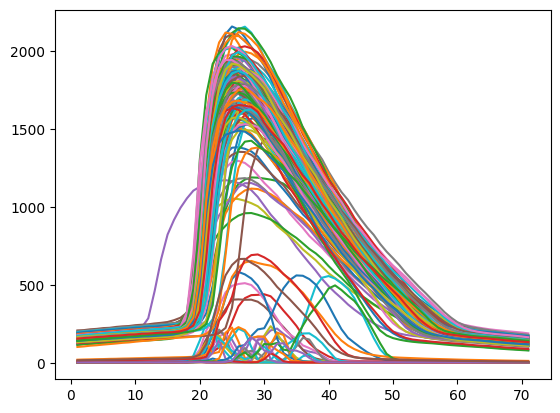

In [9]:
## For inspection only

# Group df by Metadata_Well and sort by Metadata_Z
df = df.sort_values(by='Metadata_Z')
df_grouped = df.groupby('Metadata_Well')

# Then plot the normalized variance across Z for each well
fig, ax = plt.subplots()
for name, group in df_grouped:
    ax.plot(group['Metadata_Z'], group['normalized_variance'], label=name)

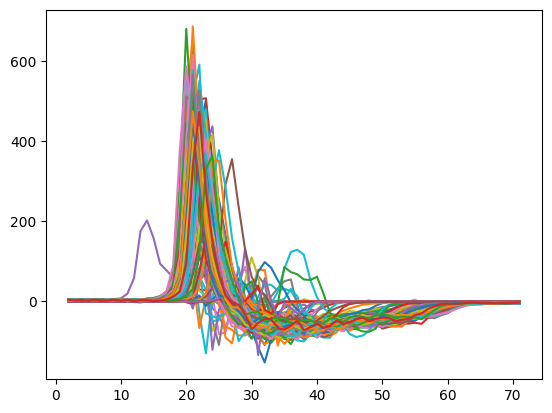

In [10]:
## For inspection only

# Group df by Metadata_Well and sort by Metadata_Z
df = df.sort_values(by='Metadata_Z')
df_grouped = df.groupby('Metadata_Well')

# Then plot the normalized variance across Z for each well
fig, ax = plt.subplots()
for name, group in df_grouped:
    ax.plot(group['Metadata_Z'], group['d_normalized_variance'], label=name)

### Inspect the first slices from our method. 

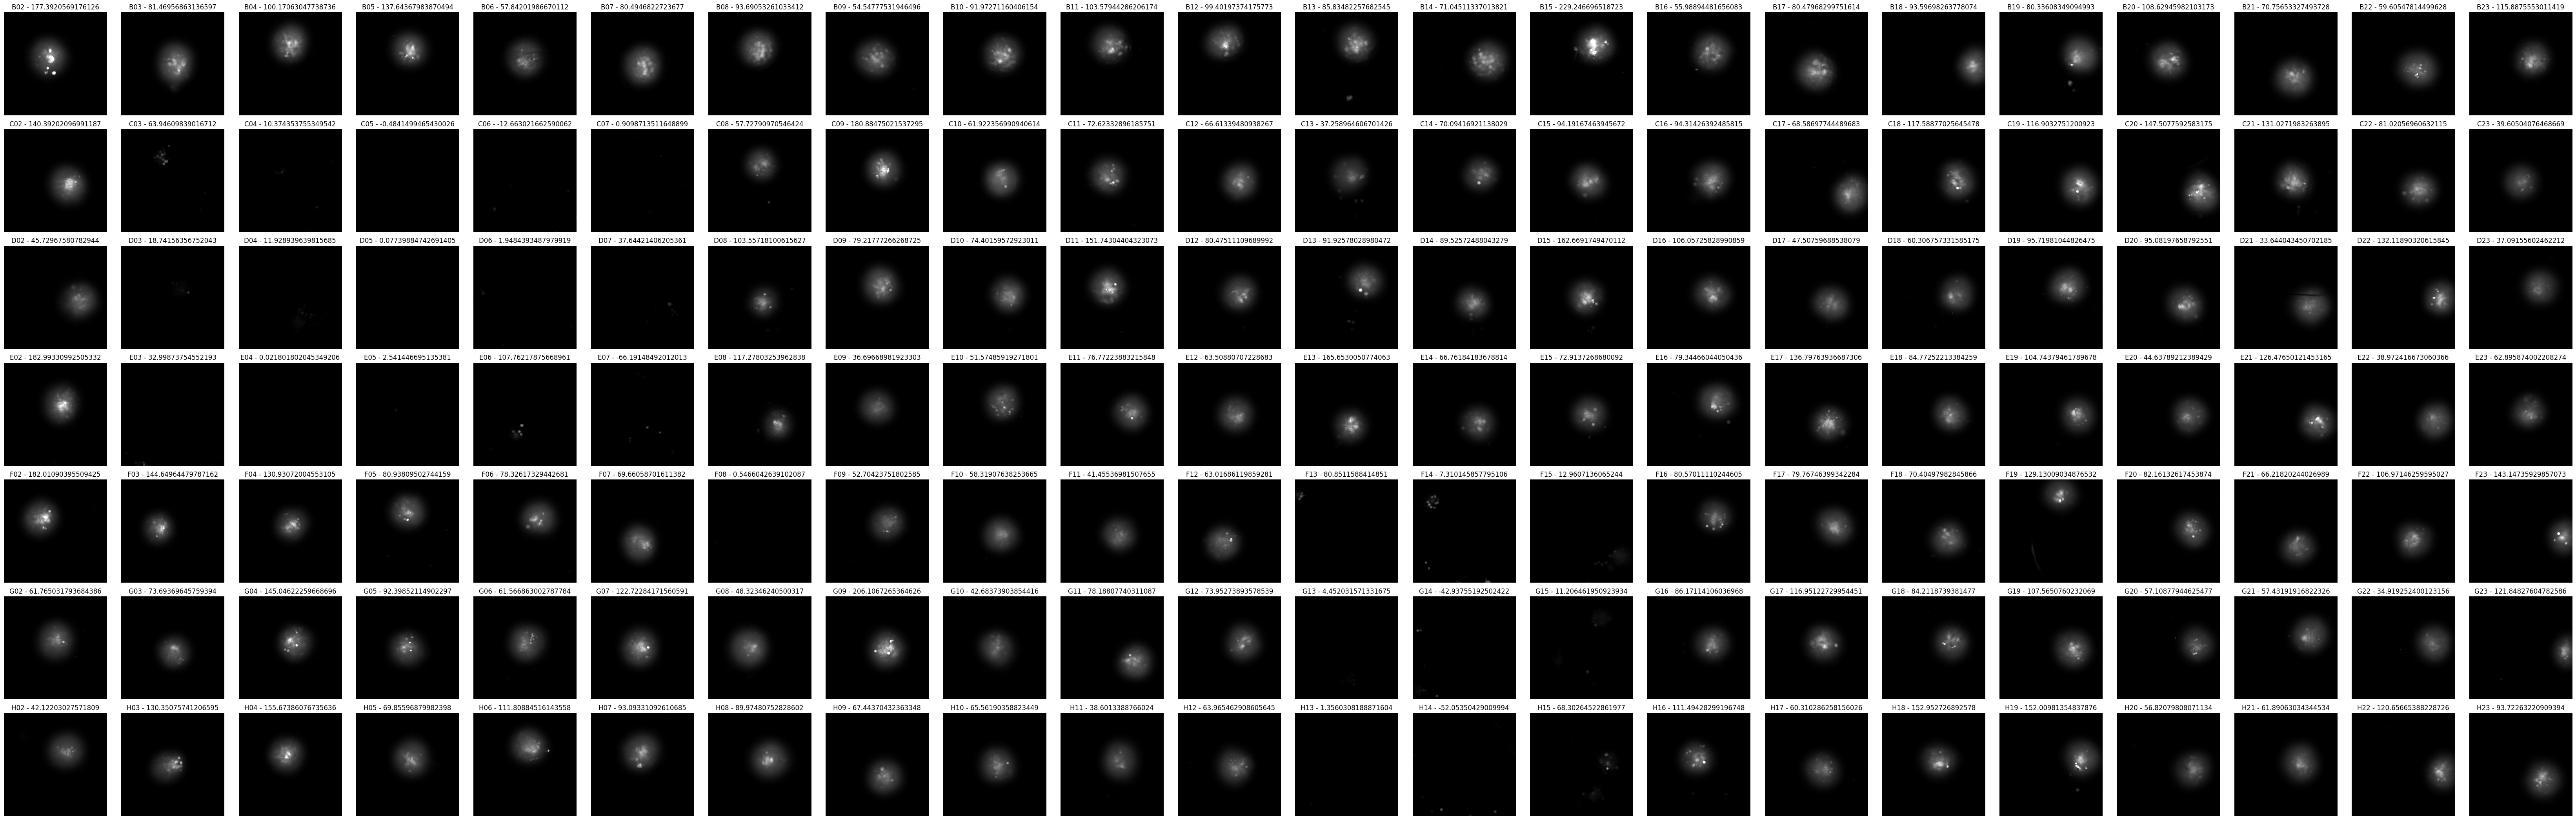

In [11]:
# 1. Filter DataFrame for your images of interest
selected = df.query('Metadata_Plane == -1').copy()

# Sort by well
selected = selected.sort_values(['Metadata_Well'])

# 2. Collect images and labels (well numbers) into lists
images = []
labels = []  # e.g. Well numbers
img_data = None
for i, row in selected.iterrows():
    image_path = row['URL_SphereDetect']
    img_data = tiff.TiffFile(image_path).asarray()
    images.append(img_data)
    
    # If your well information is in 'Metadata_Well', store it
    labels.append(str(row['Metadata_Well']) + ' - ' + str(row['d_normalized_variance']))

# 3. Determine grid layout
n_images = len(images)
n_cols = 22  # Adjust as needed
n_rows = 7  # Adjust as needed

# 4. Create figure and subplots
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3 * n_cols, 3 * n_rows),  # Adjust as needed
    squeeze=False
)

# 5. Display each image, add a title, and remove axes
for ax, img, label in zip(axes.flat, images, labels):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1500)
    ax.set_title(label)  
    ax.axis('off')

# Hide any leftover empty subplots if n_rows*n_cols > n_images
for ax in axes.flat[n_images:]:
    ax.axis('off')

plt.tight_layout()
plt.show()



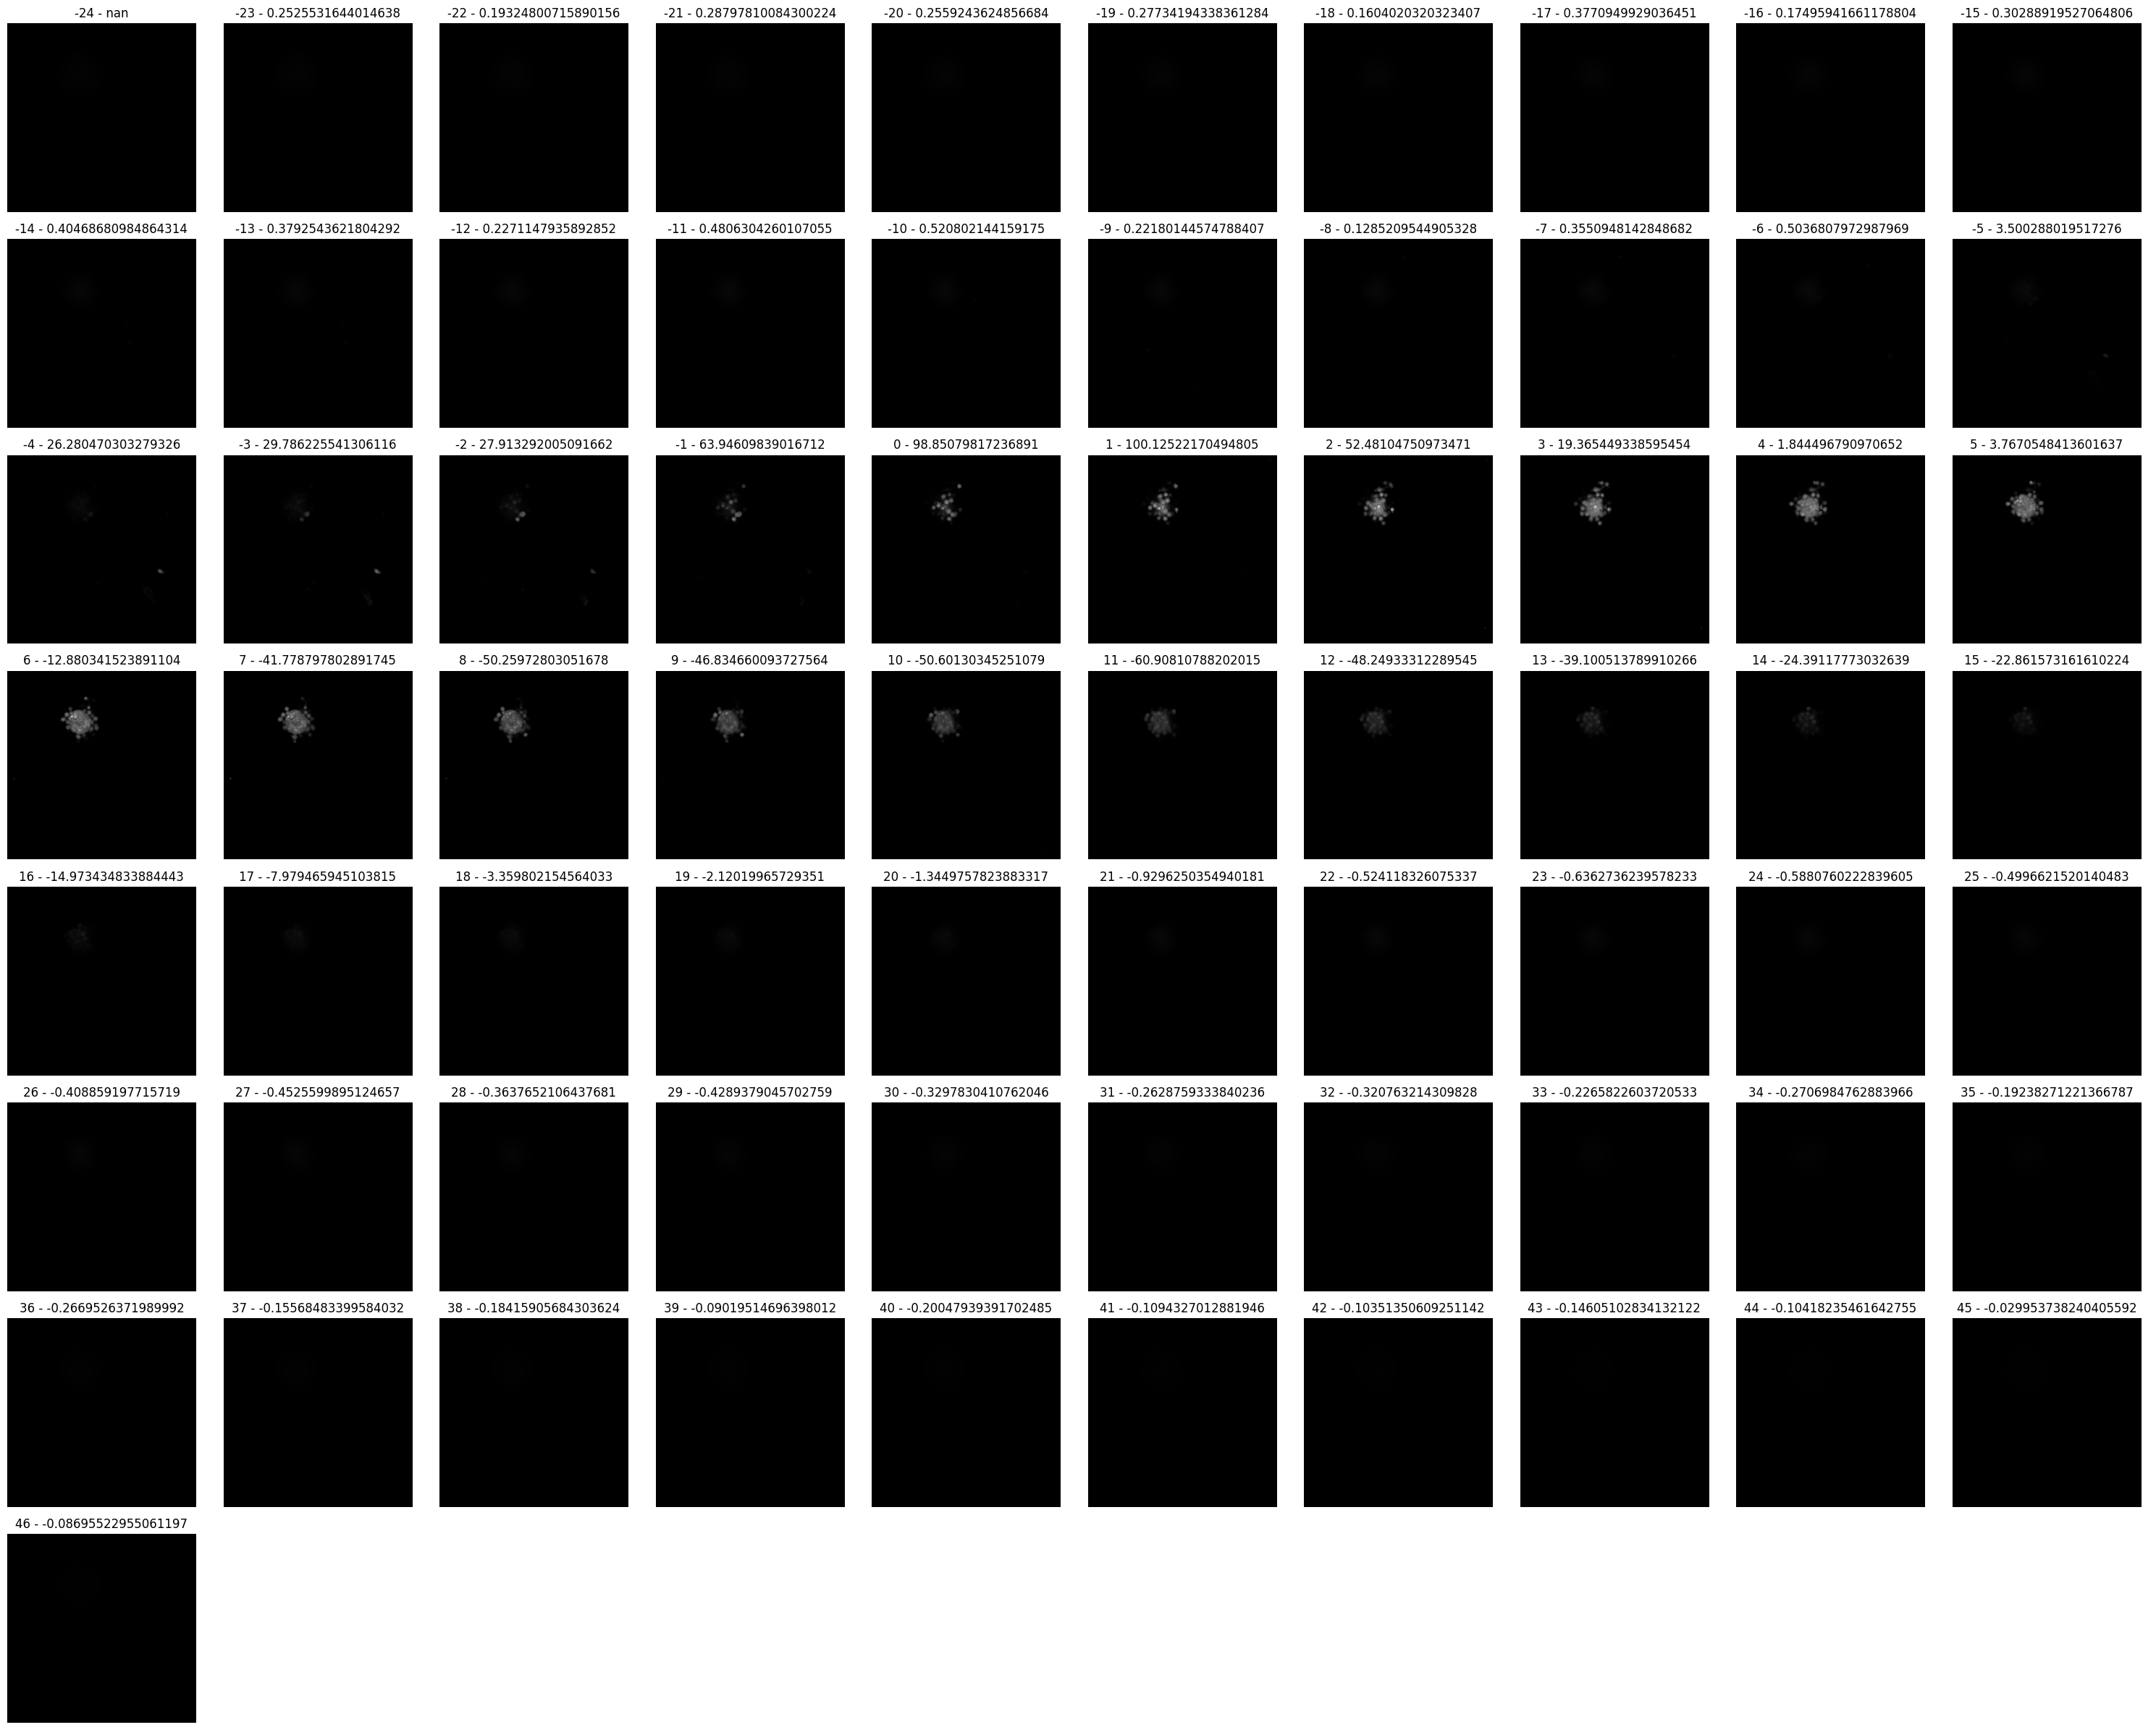

In [12]:
# Inspect a single well 

well = 'C03'

# 1. Filter DataFrame for your images of interest
selected = df.query('Metadata_Well == @well').copy()

# Sort by well
selected = selected.sort_values(['Metadata_Plane'])

# 2. Collect images and labels (well numbers) into lists
images = []
labels = []  # e.g. Well numbers
img_data = None
for i, row in selected.iterrows():
    image_path = row['URL_SphereDetect']
    img_data = tiff.TiffFile(image_path).asarray()
    images.append(img_data)
    
    # If your well information is in 'Metadata_Well', store it
    labels.append(str(row['Metadata_Plane']) + ' - ' + str(row['d_normalized_variance']))

# 3. Determine grid layout
n_images = len(images)
n_cols = 10  # Adjust as needed
n_rows = 8  # Adjust as needed

# 4. Create figure and subplots
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3 * n_cols, 3 * n_rows),  # Adjust as needed
    squeeze=False
)

# 5. Display each image, add a title, and remove axes
for ax, img, label in zip(axes.flat, images, labels):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1500)
    ax.set_title(label)  
    ax.axis('off')

# Hide any leftover empty subplots if n_rows*n_cols > n_images
for ax in axes.flat[n_images:]:
    ax.axis('off')

plt.tight_layout()
plt.show()



In [21]:
# import dask_image.ndmeasure as ndm
# import dask.array as da
from dask_image.imread import imread
from dask_image import ndmeasure 
import dask.array as da



In [20]:
# Load the images
images = imread('/mnt/external-images-pvc/spher-colo52-az/CellPainting_20241220clearedspheroidsBOMI_20241220_151510/AssayPlate_Corning_3830/*.tif')



In [22]:
# Calculate the start time
start = time.time()

# Code here

# Calculate the normalized variance for each image
normalized_variance = da.map_blocks(calculate_normalized_variance, images, dtype='float64')

df['normalized_variance'] = normalized_variance.compute()

# Calculate the end time and time taken
end = time.time()
length = end - start

# Show the results : this can be altered however you like
print("It took", length, "seconds!")

KeyboardInterrupt: 